# Reading the SEDust optics products

Each dust model ships one HDF5 file, `data/<model>/sedust_<model>.h5`, holding

* `/grid/lambda` — the model's wavelength axis, and the attribute `i_lyman`
* `/kext/*` — the size-integrated extinction curve per H nucleon
* `/qtable/<component>/*` — the $(\lambda, a_{\rm eff})$ cross sections of each
  grain population

This notebook reads both and plots them. It uses `pyutil.sedust_h5`, which is
the Python counterpart of `sed/src/sedust_product.f90`: same file, same cut,
same numbers.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# Run from anywhere inside the SEDust tree.
HERE = os.getcwd()
ROOT = HERE
while ROOT != '/' and not os.path.isdir(os.path.join(ROOT, 'pyutil')):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)
DATA = os.path.join(ROOT, 'data')

from pyutil.sedust_h5 import (model_file, read_grid, read_kext, read_qtable,
                              components, describe)

MODELS = ('astrodust', 'dl07', 'zubko')
for m in MODELS:
    print(model_file(DATA, m), os.path.exists(model_file(DATA, m)))

/nfs/mocafe/kiseon/MoCafe/Grain/SEDust_v1.00/data/astrodust/sedust_astrodust.h5 True
/nfs/mocafe/kiseon/MoCafe/Grain/SEDust_v1.00/data/dl07/sedust_dl07.h5 True
/nfs/mocafe/kiseon/MoCafe/Grain/SEDust_v1.00/data/zubko/sedust_zubko.h5 True


## What is in a file

`describe` prints the axes, the groups, their shapes and the provenance
attributes each group carries.

In [2]:
describe(model_file(DATA, 'zubko'));

/nfs/mocafe/kiseon/MoCafe/Grain/SEDust_v1.00/data/zubko/sedust_zubko.h5  (7.5 MB)
  generator    SEDust sed/make_qtable.x
  layout       cross sections are (n_a, n_lam) in h5py; lambda is the fastest Fortran axis
  model        zubko
  /grid/lambda  1201 points, 1.00000e-03 .. 1.00000e+04 um
    i_lyman = 337  ->  lambda = 9.120110e-02 um; include_euv=False gives 865 points
  /qtable
    gra
      Q_abs(121, 1201), Q_ext(121, 1201), Q_sca(121, 1201), a_eff(121,), g(121, 1201)
      rho = 2.24 g/cm^3, scatters: yes
      method: Mie on the D03 graphite dielectric functions, 1/3 E||c + 2/3 E-perp-c, free-electron term at each radius
      source: ../data/dielectric/index_CpaD03 + index_CpeD03; grids from ../data/zubko/Gra_121_1201.dat
    pah
      Q_abs(28, 1201), a_eff(28,)
      rho = 2.24 g/cm^3, scatters: no -- absorption prescription only
      method: DL07 PAH absorption cross sections, neutral
      source: qpah.f90; grids from ../data/zubko/PAH_28_1201_neu.dat
    sil
      Q_ab

## The extinction curve

`/kext` is what an RT host gets back from `dust_extinction`: the size integral
over the model's populations, per H nucleon. `include_euv=False` (the default)
returns the non-ionizing part of the axis.

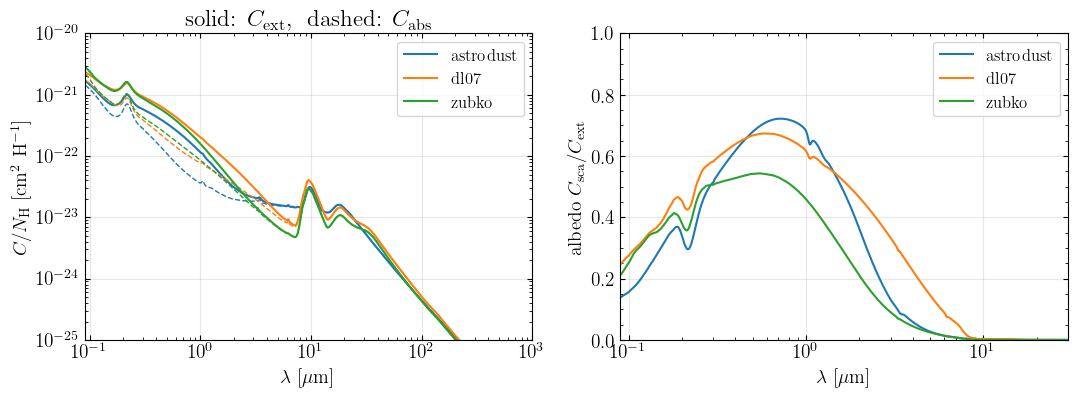

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {'astrodust': 'C0', 'dl07': 'C1', 'zubko': 'C2'}

for m in MODELS:
    k = read_kext(model_file(DATA, m))          # include_euv=False
    ax[0].loglog(k.lam, k.C_ext, color=colors[m], label=m)
    ax[0].loglog(k.lam, k.C_abs, color=colors[m], ls='--', lw=1)
    ax[1].semilogx(k.lam, k.albedo, color=colors[m], label=m)

ax[0].set_xlabel(r'$\lambda\ [\mu\mathrm{m}]$')
ax[0].set_ylabel(r'$C/N_{\rm H}\ [\mathrm{cm^2\ H^{-1}}]$')
ax[0].set_title(r'solid: $C_{\rm ext}$,\ \ dashed: $C_{\rm abs}$')
ax[0].set_xlim(0.09, 1e3); ax[0].set_ylim(1e-25, 1e-20)
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].set_xlabel(r'$\lambda\ [\mu\mathrm{m}]$')
ax[1].set_ylabel(r'albedo $C_{\rm sca}/C_{\rm ext}$')
ax[1].set_xlim(0.09, 30); ax[1].set_ylim(0, 1)
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout()

## `include_euv`: one axis, two views

The file carries the widest axis the model has and records `i_lyman`, the first
index at or longward of the Lyman limit. `include_euv=False` returns
`lambda[i_lyman:]` and the same slice of every wavelength-indexed array — so the
non-ionizing product is a *view* of the wide one, not a second file to keep in
step with it.

astrodust: 1762 wide, 1129 narrow, i_lyman = 634
narrow axis IS the wide axis sliced at i_lyman: True


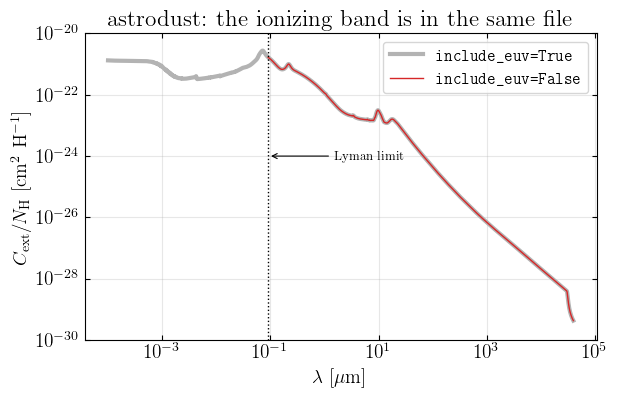

In [4]:
m = 'astrodust'
wide = read_grid(model_file(DATA, m), include_euv=True)
narrow = read_grid(model_file(DATA, m), include_euv=False)
print(f'{m}: {wide.n} wide, {narrow.n} narrow, i_lyman = {wide.i_lyman}')
print('narrow axis IS the wide axis sliced at i_lyman:',
      np.array_equal(narrow.lam, wide.lam[wide.i_lyman - 1:]))

kw = read_kext(model_file(DATA, m), include_euv=True)
kn = read_kext(model_file(DATA, m), include_euv=False)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.loglog(kw.lam, kw.C_ext, color='0.7', lw=3, label=r'\texttt{include\_euv=True}')
ax.loglog(kn.lam, kn.C_ext, color='C3', lw=1, label=r'\texttt{include\_euv=False}')
ax.axvline(0.0912, color='k', ls=':', lw=1)
ax.annotate(r'Lyman limit', xy=(0.0912, 1e-24), xytext=(1.5, 1e-24),
            fontsize=9, va='center',
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_ylim(1e-30, 1e-20)
ax.set_xlabel(r'$\lambda\ [\mu\mathrm{m}]$')
ax.set_ylabel(r'$C_{\rm ext}/N_{\rm H}\ [\mathrm{cm^2\ H^{-1}}]$')
ax.set_title('astrodust: the ionizing band is in the same file')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

## The cross-section tables

`/qtable/<component>` holds $Q$ on the model's $(\lambda, a_{\rm eff})$ grid.
The arrays come back `(n_a, n_lam)`: each grain radius is one contiguous
spectrum, and the wavelength is the last axis.

A population whose cross sections are an absorption prescription rather than a
Mie solution — the PAHs — carries `Q_abs` alone, and `Q_ext`, `Q_sca` and `g`
come back `None` with `scatters` False. Nothing is invented on read.

In [5]:
m = 'dl07'
print(m, 'components:', components(model_file(DATA, m)))
for c in components(model_file(DATA, m)):
    q = read_qtable(model_file(DATA, m), c)
    print(f'  {c:<8s} Q_abs {q.Q_abs.shape}  rho = {q.rho_bulk} g/cm^3  '
          f'scatters = {q.scatters}')

dl07 components: ['gra', 'pah_ion', 'pah_neu', 'sil']
  gra      Q_abs (84, 1129)  rho = 2.2 g/cm^3  scatters = True
  pah_ion  Q_abs (84, 1129)  rho = 2.2 g/cm^3  scatters = False
  pah_neu  Q_abs (84, 1129)  rho = 2.2 g/cm^3  scatters = False
  sil      Q_abs (84, 1129)  rho = 3.5 g/cm^3  scatters = True


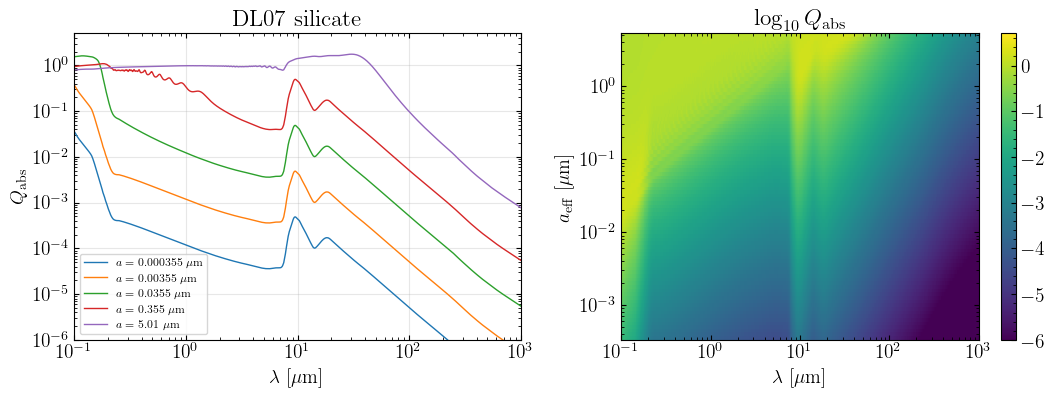

In [6]:
q = read_qtable(model_file(DATA, 'dl07'), 'sil')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for ja in (0, 20, 40, 60, 83):
    ax[0].loglog(q.lam, q.Q_abs[ja], lw=1,
                 label=r'$a = ' + f'{q.a_eff[ja]:.3g}' + r'\ \mu\mathrm{m}$')
ax[0].set_xlabel(r'$\lambda\ [\mu\mathrm{m}]$')
ax[0].set_ylabel(r'$Q_{\rm abs}$')
ax[0].set_title('DL07 silicate')
ax[0].set_xlim(0.1, 1e3); ax[0].set_ylim(1e-6, 5)
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

# The whole table as a map.  Wavelength on x, radius on y, both logarithmic.
im = ax[1].pcolormesh(q.lam, q.a_eff, np.log10(np.maximum(q.Q_abs, 1e-12)),
                      shading='auto', cmap='viridis', vmin=-6, vmax=0.7)
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_xlim(0.1, 1e3)
ax[1].set_xlabel(r'$\lambda\ [\mu\mathrm{m}]$')
ax[1].set_ylabel(r'$a_{\rm eff}\ [\mu\mathrm{m}]$')
ax[1].set_title(r'$\log_{10} Q_{\rm abs}$')
fig.colorbar(im, ax=ax[1])
fig.tight_layout()

## Mass opacity

`/kext/K_abs` is $C_{\rm abs}/N_{\rm H}$ divided by the model's dust mass per H,
which the group records as `M_dust_per_H`. It is the one wavelength-independent
constant that turns a cross section per H into a mass opacity.

astrodust  M_dust/N_H = 1.1849e-26 g/H
dl07       M_dust/N_H = 1.7502e-26 g/H
zubko      M_dust/N_H = 1.4439e-26 g/H


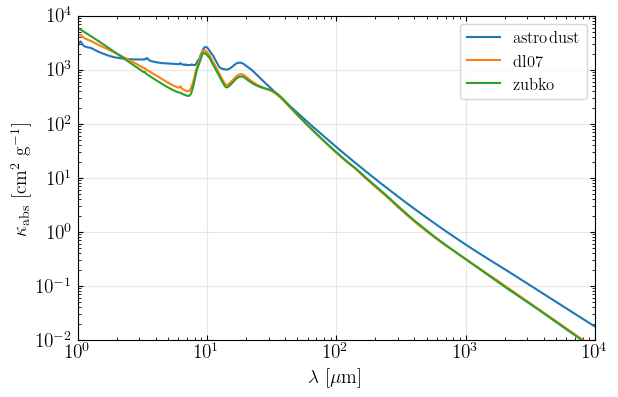

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
for m in MODELS:
    k = read_kext(model_file(DATA, m))
    print(f'{m:<10s} M_dust/N_H = {k.M_dust_per_H:.4e} g/H')
    ax.loglog(k.lam, k.K_abs, color=colors[m], label=m)
    # K_abs is exactly C_abs / M_dust_per_H -- check, do not assume.
    assert np.allclose(k.K_abs, k.C_abs / k.M_dust_per_H, rtol=1e-12)

ax.set_xlabel(r'$\lambda\ [\mu\mathrm{m}]$')
ax.set_ylabel(r'$\kappa_{\rm abs}\ [\mathrm{cm^2\ g^{-1}}]$')
ax.set_xlim(1, 1e4); ax.set_ylim(1e-2, 1e4)
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

## Provenance

Every group records what produced it and from which inputs. That is not
decoration: an optics table in this tree once named a dielectric function it had
demonstrably not been computed from, and a stale label of that kind costs real
time to unpick.

`text_product` names the `.dat` file the same numbers were also written to.
Those text products are regenerable — `sed/make_qtable.x` and `sed/calc_kext.x`
rewrite them in minutes — so they are not tracked, and the attribute may well
name a file this checkout does not have. The HDF5 file is the primary form; the
notebook above never opens a `.dat`.

In [8]:
q = read_qtable(model_file(DATA, 'zubko'), 'sil')
for key in ('method', 'source', 'rho_bulk_g_cm3'):
    print(f'{key:>16s}: {q.attrs[key]}')

k = read_kext(model_file(DATA, 'zubko'))
for key in ('method', 'size_dist_file', 'text_product'):
    print(f'{key:>16s}: {k.attrs[key]}')

          method: Mie on the D03 astrosilicate dielectric function
          source: ../data/dielectric/index_silD03; grids from ../data/zubko/suvSil_121_1201.dat
  rho_bulk_g_cm3: 3.5
          method: size integral over the built model's populations, the same call dust_extinction serves from
  size_dist_file: ../data/zubko/ZDA_BARE_GR_S_Config.dat
    text_product: ../data/zubko/kext_zubko_BARE_GR_S_euv.dat
